In [2]:
import pandas as pd
df = pd.read_csv("../data/train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [5]:
df = df.fillna(method="ffill")

In [6]:
df.isnull().sum() #verify missing filled

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

0

In [10]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [12]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-272.7875000000001
500.6405000000001


In [13]:
df = df[
    (df["Sales"] >= lower_bound)
    &
    (df["Sales"] <= upper_bound)
]

In [14]:
df.shape

(8655, 18)

In [15]:
df.to_csv(
    "../data/superstore_cleaned.csv",
    index=False
)

# Day 5-6: Exploratory Data Analysis (EDA)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8655 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         8655 non-null   int64         
 1   Order ID       8655 non-null   object        
 2   Order Date     8655 non-null   datetime64[ns]
 3   Ship Date      8655 non-null   datetime64[ns]
 4   Ship Mode      8655 non-null   object        
 5   Customer ID    8655 non-null   object        
 6   Customer Name  8655 non-null   object        
 7   Segment        8655 non-null   object        
 8   Country        8655 non-null   object        
 9   City           8655 non-null   object        
 10  State          8655 non-null   object        
 11  Postal Code    8655 non-null   float64       
 12  Region         8655 non-null   object        
 13  Product ID     8655 non-null   object        
 14  Category       8655 non-null   object        
 15  Sub-Category   8655 non-nu

In [17]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,8655.000000,8655,8655,8655.000000,8655.000000
mean,4916.320508,2017-05-04 04:21:32.755632896,2017-05-08 03:36:17.469670656,55443.406355,93.213330
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2454.500000,2016-05-29 00:00:00,2016-06-02 00:00:00,23320.000000,15.014000
50%,4925.000000,2017-07-01 00:00:00,2017-07-03 00:00:00,60067.000000,40.880000
75%,7362.500000,2018-05-18 00:00:00,2018-05-21 12:00:00,90004.000000,124.382000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,500.240000
std,2830.949018,NaN,NaN,31957.075620,114.693292


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

Histogram

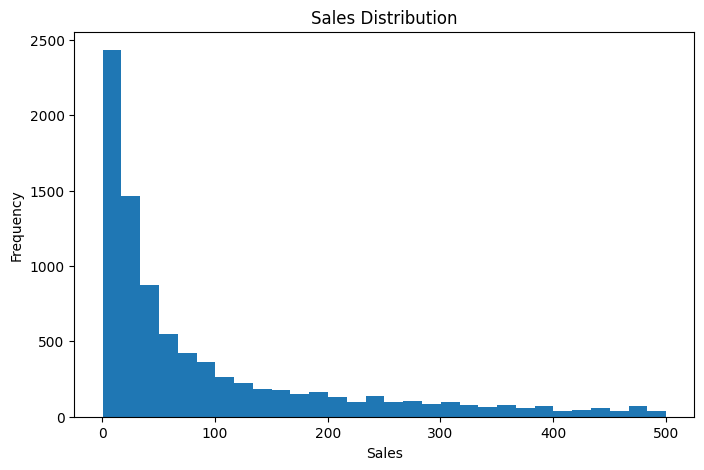

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Boxplot

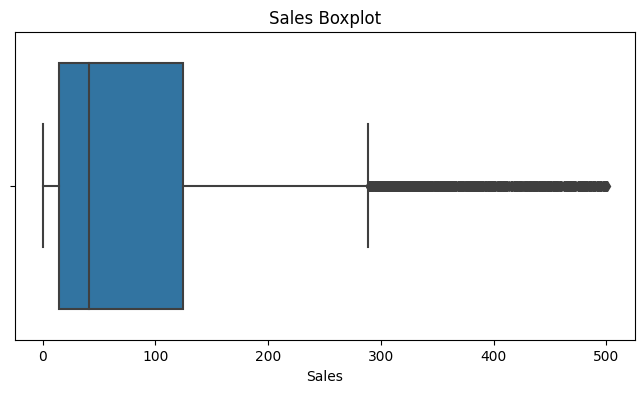

In [20]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Sales"])

plt.title("Sales Boxplot")

plt.show()

Bar Chart (Category)

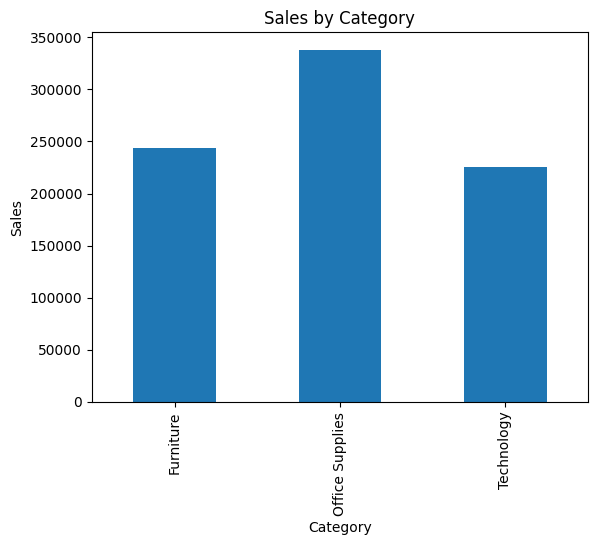

In [21]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Bar Chart (Region)

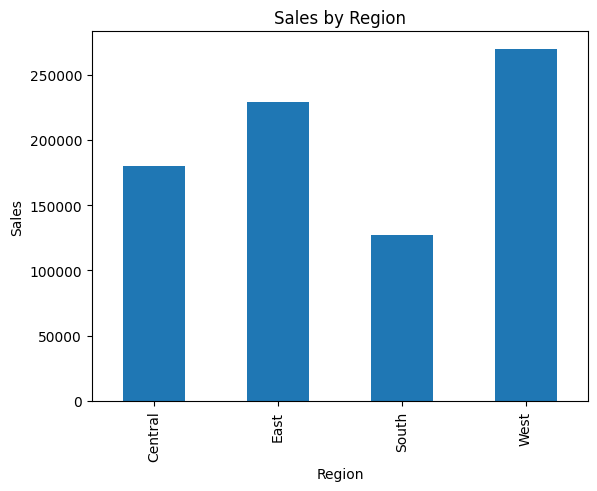

In [22]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

Correlation Heatmap

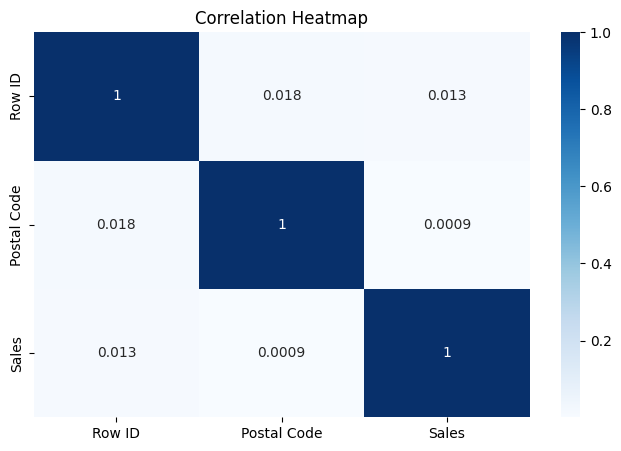

In [23]:
plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

Line Chart

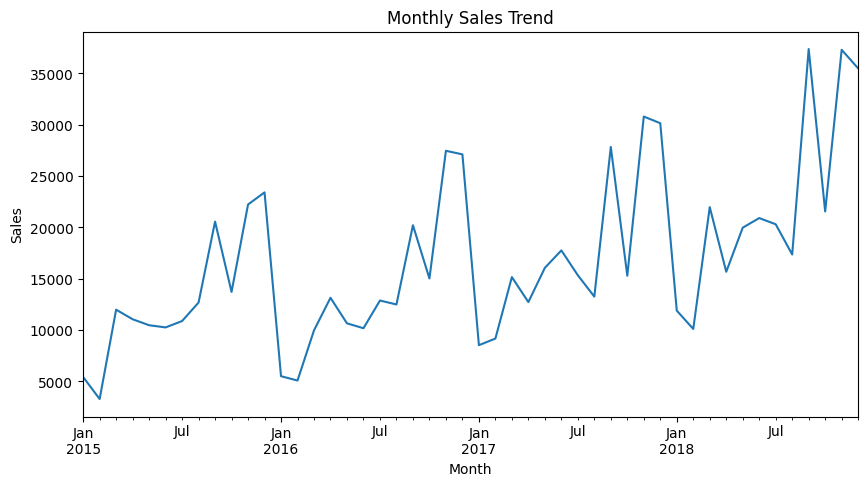

In [25]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

## Key Insights

1. Technology category recorded the highest sales among all categories.

2. Sales varied across different regions, highlighting regional demand differences.

3. The histogram shows that most sales values are concentrated within a specific range.

4. The correlation heatmap provides relationships between numerical features.

5. The monthly sales trend indicates variations in sales over time.